# ¿Puede una IA adivinar cómo reaccionará la gente antes de preguntarle?

Un equipo le pidió a GPT-4 que predijera el resultado de **70 experimentos sociales reales** —de esos donde le muestras a miles de personas dos versiones de un mensaje y mides cuál las mueve más. La IA no corrió ningún experimento. Solo leyó el diseño y adivinó.

Sus predicciones se parecieron a la realidad tanto como las de un grupo de humanos expertos. Abramos los datos y veamos exactamente cuánto acertó —y dónde falló.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Hewitt et al. (2026), *Large language models can predict the results of social science experiments*, **Nature**.
**DOI:** [10.1038/s41586-026-10742-x](https://doi.org/10.1038/s41586-026-10742-x)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-10-llm-predice-experimentos-sociales/notebook.ipynb)

**Video:** [Pendiente]

## Qué hay dentro de estos datos

Los autores armaron un archivo de **70 experimentos** preregistrados, representativos de la población de EE. UU. —en total **469 efectos** medidos sobre **119.330 participantes**. Cada experimento compara condiciones (por ejemplo: "¿aprueba el manejo de X?" con un mensaje frente a otro) y mide el *efecto de tratamiento*: cuánto cambia la respuesta al cambiar el estímulo.

Luego le pidieron a GPT-4 que simulara cómo respondería una muestra representativa de estadounidenses a cada estímulo, y de ahí sacaron un efecto **predicho**. El detalle clave: el corte de entrenamiento de GPT-4 es anterior a la publicación de muchos de estos estudios —así que para buena parte, la IA no pudo haberlos leído.

Cada punto que vamos a explorar es un contraste: efecto **real** medido con gente de verdad, contra efecto **predicho** por la IA.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
R_HUMANOS_REF = 0.888        # correlación de los pronósticos humanos combinados (referencia)
MODELO_FOCO = 'gpt-4'        # modelo protagonista de la comparación
FUENTE = 'Fuente: Hewitt et al. (2026), Nature | Datos: Code Ocean capsule 9843791'

COLOR_DATOS = '#2563EB'      # azul CaM — IA / efecto predicho / no publicados
COLOR_ALERTA = '#DC2626'     # rojo — sobreestimación / modelo viejo
COLOR_SECUND = '#059669'     # emerald — humanos / publicados
COLOR_REFERENCIA = '#D97706' # amber — línea de acierto perfecto
COLOR_VIOLETA = '#7C3AED'    # violeta — modelos abiertos
COLOR_GRIS = '#BBBBBB'       # gris — contexto

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# Carga de datos
pred = pd.read_csv('datos/predicciones_vs_reales.csv')   # efecto real vs predicho, 3356 contrastes
modelos = pd.read_csv('datos/correlacion_por_modelo.csv') # correlación por modelo
mega = pd.read_csv('datos/gpt_vs_expertos_megastudias.csv') # archivo secundario: megastudios

# Correlación general (Pearson) entre lo predicho y lo real
r_pool, _ = stats.pearsonr(pred['llm_predicted_effect'], pred['actual_effect'])
sp_pool, _ = stats.spearmanr(pred['llm_predicted_effect'], pred['actual_effect'])

n_contrastes = f'{len(pred):,}'.replace(',', '.')   # miles con punto (español)
print(f'Contrastes: {n_contrastes}  |  Estudios: {pred["study"].nunique()}  |  Participantes: 119.330')
print(f'Correlación predicho vs real (Pearson): r = {r_pool:.3f}')
print(f'Correlación de rangos (Spearman):       r = {sp_pool:.3f}')
print(f'Referencia humanos (pronósticos combinados): r_adj = {R_HUMANOS_REF}')

Contrastes: 3.356  |  Estudios: 70  |  Participantes: 119.330
Correlación predicho vs real (Pearson): r = 0.805
Correlación de rangos (Spearman):       r = 0.684
Referencia humanos (pronósticos combinados): r_adj = 0.888


## Aquí está.

Cada punto es un experimento. El eje horizontal es lo que la IA predijo; el vertical, lo que de verdad pasó con la gente.

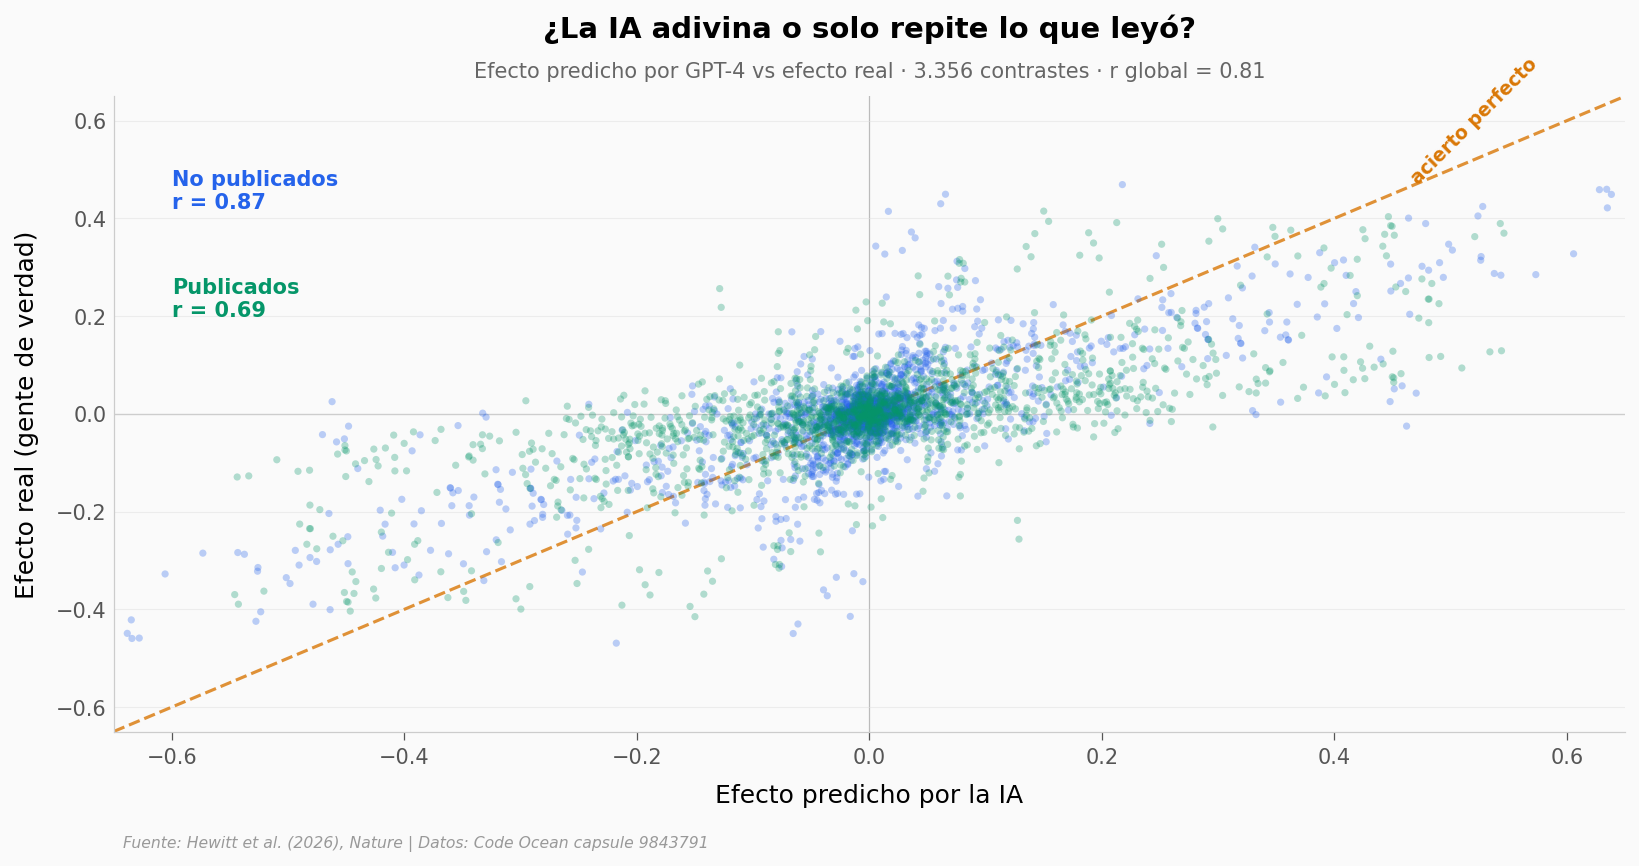

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Línea de acierto perfecto (diagonal): si la IA acertara siempre, todo caería aquí
lim = 0.65
ax.plot([-lim, lim], [-lim, lim], color=COLOR_REFERENCIA, linewidth=1.5,
        linestyle='--', alpha=0.8, zorder=2)
ax.text(0.52, 0.60, 'acierto perfecto', color=COLOR_REFERENCIA, fontsize=9,
        fontweight='bold', rotation=45, ha='center', va='center')

# Puntos separados por si el estudio estaba publicado antes del corte de la IA
grupos = [
    ('unpublished', COLOR_DATOS, 'No publicados (la IA no los vio)'),
    ('published',   COLOR_SECUND, 'Ya publicados'),
]
for g, color, _lab in grupos:
    sub = pred[pred['group'] == g]
    ax.scatter(sub['llm_predicted_effect'], sub['actual_effect'], color=color,
               s=12, alpha=0.30, edgecolors='none', zorder=4)

# Correlaciones por grupo (para las etiquetas inline)
r_unpub, _ = stats.pearsonr(pred[pred.group=='unpublished'].llm_predicted_effect,
                            pred[pred.group=='unpublished'].actual_effect)
r_pub, _ = stats.pearsonr(pred[pred.group=='published'].llm_predicted_effect,
                          pred[pred.group=='published'].actual_effect)
ax.text(-0.60, 0.50, f'No publicados\nr = {r_unpub:.2f}', color=COLOR_DATOS,
        fontsize=10, fontweight='bold', va='top')
ax.text(-0.60, 0.28, f'Publicados\nr = {r_pub:.2f}', color=COLOR_SECUND,
        fontsize=10, fontweight='bold', va='top')

ax.set_title('¿La IA adivina o solo repite lo que leyó?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Efecto predicho por GPT-4 vs efecto real · {n_contrastes} contrastes · r global = {r_pool:.2f}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Efecto predicho por la IA')
ax.set_ylabel('Efecto real (gente de verdad)')
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.axhline(0, color=COLOR_GRIS, linewidth=0.6, zorder=1)
ax.axvline(0, color=COLOR_GRIS, linewidth=0.6, zorder=1)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_prediccion_vs_real.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que salta a la vista: la nube sigue la diagonal. Cuando la IA dice "este mensaje mueve mucho a la gente", suele tener razón sobre la dirección y el orden de magnitud.

Y hay un detalle que vale oro. Los estudios que la IA **no pudo leer** —los que salieron después de su corte de entrenamiento— se predicen incluso mejor (r = 0,87) que los ya publicados (r = 0,69). Si la IA solo estuviera recitando papers que memorizó, esperaríamos lo contrario. Esto apunta a que está capturando algo de cómo reacciona la gente, no solo devolviendo resultados vistos.

Con cuidado: es un patrón dentro de este archivo, no una ley. Pero es justo el control que uno querría ver.

## ¿Es GPT-4 especial, o cualquier modelo sirve?

El equipo repitió el ejercicio con varios modelos —y con humanos como vara de medir. Comparemos qué tan cerca quedó cada uno del efecto real.

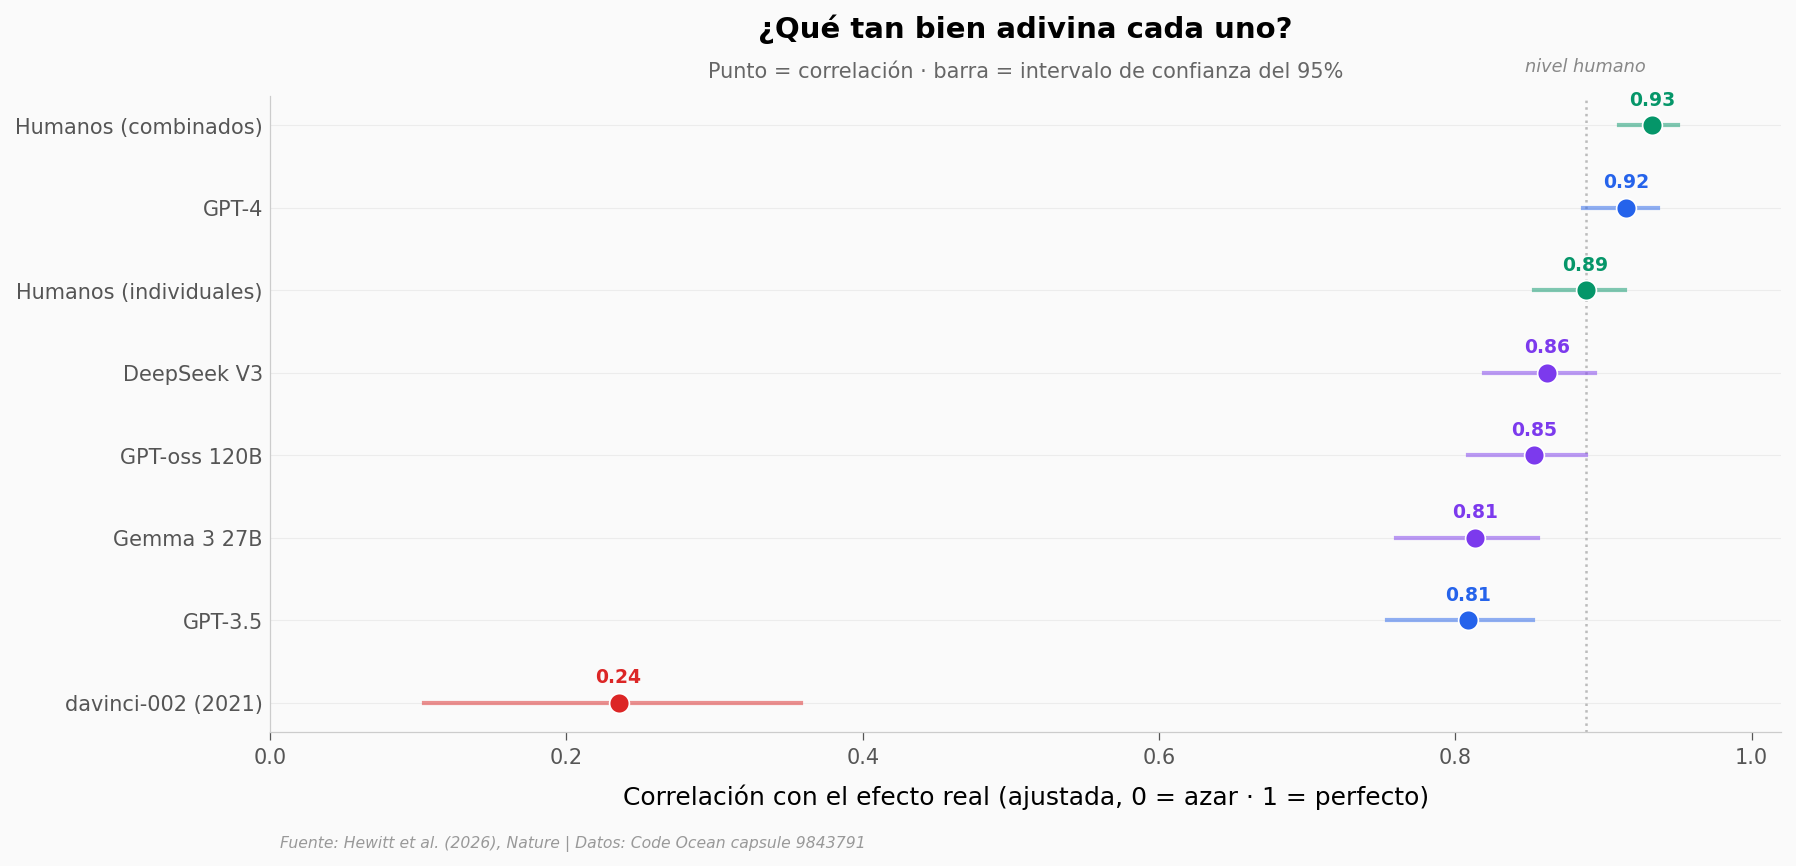

In [3]:
# Ordenar modelos por correlación ajustada (de mayor a menor)
m = modelos.copy()
etiquetas = {
    'combined': 'Humanos (combinados)', 'human': 'Humanos (individuales)',
    'gpt-4': 'GPT-4', 'gpt-3.5-turbo': 'GPT-3.5',
    'deepseek/deepseek-chat-v3-0324': 'DeepSeek V3', 'openai/gpt-oss-120b': 'GPT-oss 120B',
    'google/gemma-3-27b-it': 'Gemma 3 27B', 'davinci-002': 'davinci-002 (2021)',
}
color_clase = {'human': COLOR_SECUND, 'gpt': COLOR_DATOS, 'open': COLOR_VIOLETA}
m['nombre'] = m['model'].map(etiquetas)
m = m.sort_values('r_adj').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5.5))
y = np.arange(len(m))
for i, row in m.iterrows():
    c = COLOR_ALERTA if row['model'] == 'davinci-002' else color_clase[row['model_class']]
    ax.plot([row['r_adj_ci_lo'], row['r_adj_ci_hi']], [i, i], color=c, linewidth=2, alpha=0.5, zorder=3)
    ax.scatter(row['r_adj'], i, color=c, s=90, edgecolors='white', linewidths=0.8, zorder=5)
    ax.text(row['r_adj'], i + 0.24, f"{row['r_adj']:.2f}", color=c, fontsize=9,
            fontweight='bold', ha='center')

ax.set_yticks(y)
ax.set_yticklabels(m['nombre'], fontsize=10)
ax.set_xlim(0, 1.02)
ax.set_xlabel('Correlación con el efecto real (ajustada, 0 = azar · 1 = perfecto)')
ax.set_title('¿Qué tan bien adivina cada uno?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Punto = correlación · barra = intervalo de confianza del 95%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Banda de referencia: nivel humano individual
ax.axvline(R_HUMANOS_REF, color=COLOR_GRIS, linewidth=1.2, linestyle=':', zorder=2)
ax.text(R_HUMANOS_REF, len(m) - 0.35, 'nivel humano', color='#888888',
        fontsize=8.5, ha='center', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/comparacion_modelos.png', dpi=200, bbox_inches='tight')
plt.show()

## Pero hay una trampa: la IA exagera

Correlación alta no es lo mismo que acierto exacto. Los modelos buenos ordenan bien los efectos —saben cuál mueve más que cuál—, pero **inflan el tamaño**. Cuando la IA predice un efecto grande, el efecto real suele ser más pequeño.

¿Cuánto exagera? Comparemos la magnitud de lo que predijo contra la de lo que pasó.

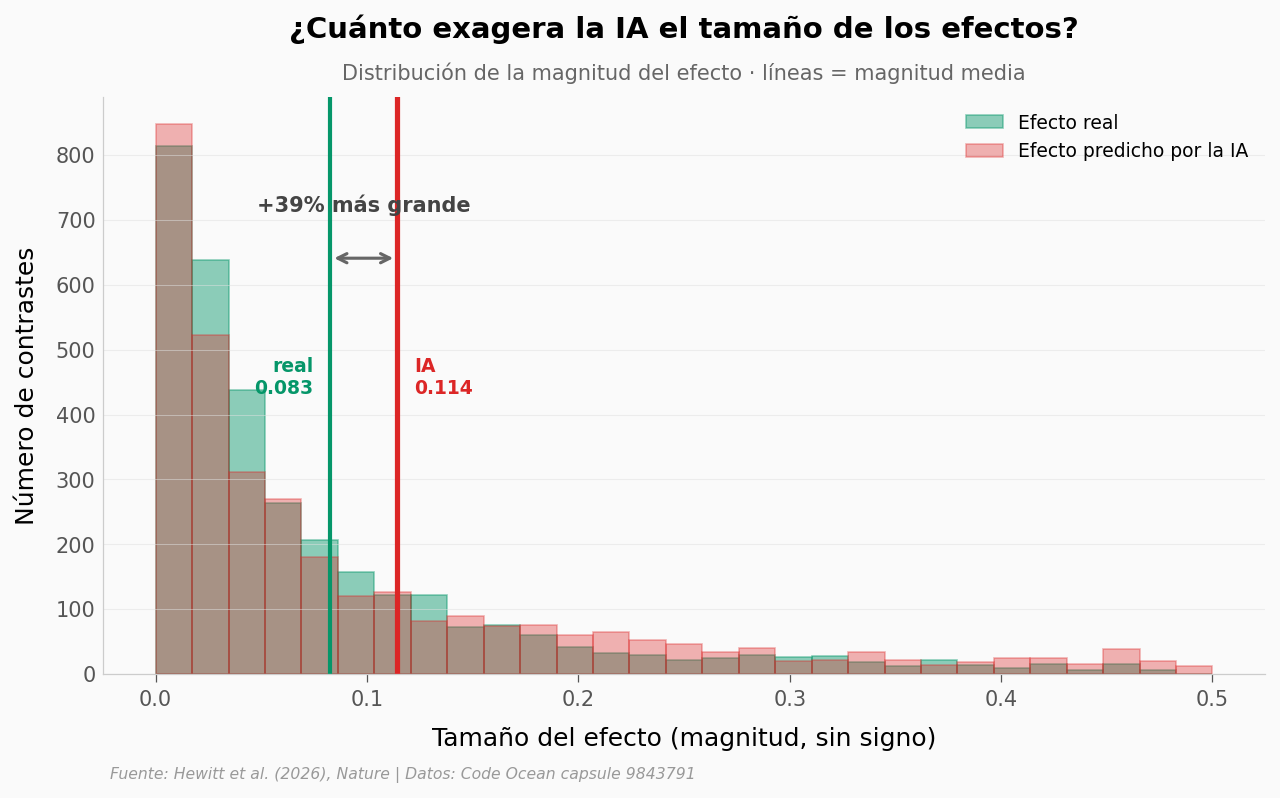

Pendiente real~predicho = 0.55  (si fuera 1, no exageraría; <1 = exagera)
La IA predice efectos, en promedio, 39% más grandes de lo que son.


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

mag_real = pred['actual_effect'].abs()
mag_pred = pred['llm_predicted_effect'].abs()
media_real = mag_real.mean()
media_pred = mag_pred.mean()

bins = np.linspace(0, 0.5, 30)
ax.hist(mag_real, bins=bins, color=COLOR_SECUND, alpha=0.45,
        edgecolor=COLOR_SECUND, linewidth=0.8, label='Efecto real')
ax.hist(mag_pred, bins=bins, color=COLOR_ALERTA, alpha=0.35,
        edgecolor=COLOR_ALERTA, linewidth=0.8, label='Efecto predicho por la IA')

y_max = ax.get_ylim()[1]
ax.axvline(media_real, color=COLOR_SECUND, linewidth=2.0)
ax.axvline(media_pred, color=COLOR_ALERTA, linewidth=2.5)

# Flecha que marca cuánto infla la IA la magnitud media
ax.annotate('', xy=(media_pred, y_max * 0.72), xytext=(media_real, y_max * 0.72),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ratio = media_pred / media_real
ax.text((media_real + media_pred) / 2, y_max * 0.80,
        f'+{(ratio-1)*100:.0f}% más grande', color='#444444', fontsize=10,
        fontweight='bold', ha='center')
ax.text(media_real - 0.008, y_max * 0.55, f'real\n{media_real:.3f}', color=COLOR_SECUND,
        fontsize=9, fontweight='bold', ha='right', va='top')
ax.text(media_pred + 0.008, y_max * 0.55, f'IA\n{media_pred:.3f}', color=COLOR_ALERTA,
        fontsize=9, fontweight='bold', ha='left', va='top')

ax.set_title('¿Cuánto exagera la IA el tamaño de los efectos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de la magnitud del efecto · líneas = magnitud media',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Tamaño del efecto (magnitud, sin signo)')
ax.set_ylabel('Número de contrastes')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sobreestimacion.png', dpi=200, bbox_inches='tight')
plt.show()

# Pendiente de regresión: confirma la sobreestimación (real ~ predicho)
slope, intercept, rr, pv, se = stats.linregress(pred['llm_predicted_effect'], pred['actual_effect'])
print(f'Pendiente real~predicho = {slope:.2f}  (si fuera 1, no exageraría; <1 = exagera)')
print(f'La IA predice efectos, en promedio, {(ratio-1)*100:.0f}% más grandes de lo que son.')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las predicciones de la IA se correlacionan fuerte con los efectos reales | ✅ | Pearson r = 0,80 sobre 3.356 contrastes (nuestro cálculo, sin ponderar). A nivel de estudio el paper reporta r = 0,85 crudo / 0,92 ajustado por error de medición |
| Acierta incluso en estudios que no pudo haber leído | ✅ | No publicados antes del corte: r = 0,87; publicados: r = 0,69. Es un patrón dentro de este archivo, no una garantía universal |
| GPT-4 queda a la altura de los pronósticos humanos | ✅ | r ajustado 0,92 (GPT-4) vs 0,89–0,93 (humanos). Modelos abiertos detrás (0,81–0,86); el viejo davinci-002 se cae a 0,24 |
| La IA sobreestima sistemáticamente el tamaño de los efectos | ✅ | Magnitud media predicha 0,114 vs real 0,082 (+39%); pendiente de regresión 0,55 (<1) |
| En experimentos de campo (megastudios) el acierto baja | ⚠️ | r de GPT cae a ~0,34, comparable a expertos humanos (~0,26). Correlación de rangos global (Spearman 0,68) también más modesta que la de Pearson |

> **Limitaciones:** (1) Solo experimentos de encuesta representativos de EE. UU.; no generaliza a otras culturas ni garantiza comportamiento real. (2) La correlación de Pearson se apoya en la estructura simétrica de los contrastes (A-vs-B y B-vs-A); la de rangos (Spearman 0,68) es más conservadora. (3) Correlación ≠ exactitud: la IA ordena bien pero infla magnitudes, así que no sirve para estimar el tamaño exacto de un efecto. (4) "Predecir" aquí es a nivel agregado de un grupo, no de una persona.

## Ahora tú

- **¿La IA le gana a los expertos humanos en el mundo real?** El archivo secundario (`mega`) tiene 15 *megastudios* —experimentos de campo enormes— con la correlación de GPT y la de pronosticadores expertos. Corre la celda de abajo y compáralas.
- **¿Dónde falla más: encuestas o campo?** En `mega`, la columna `exp_type` separa "Survey experiments" de "Field experiments". ¿En cuál acierta más la IA? (pista: agrupa por `exp_type` y saca la media de `r`).
- **¿Y si subes la exigencia?** En la celda de sobreestimación, cambia el rango de `bins` para hacer zoom en los efectos grandes (`np.linspace(0.15, 0.5, 20)`). ¿Ahí la brecha entre lo real y lo predicho se agranda o se achica?

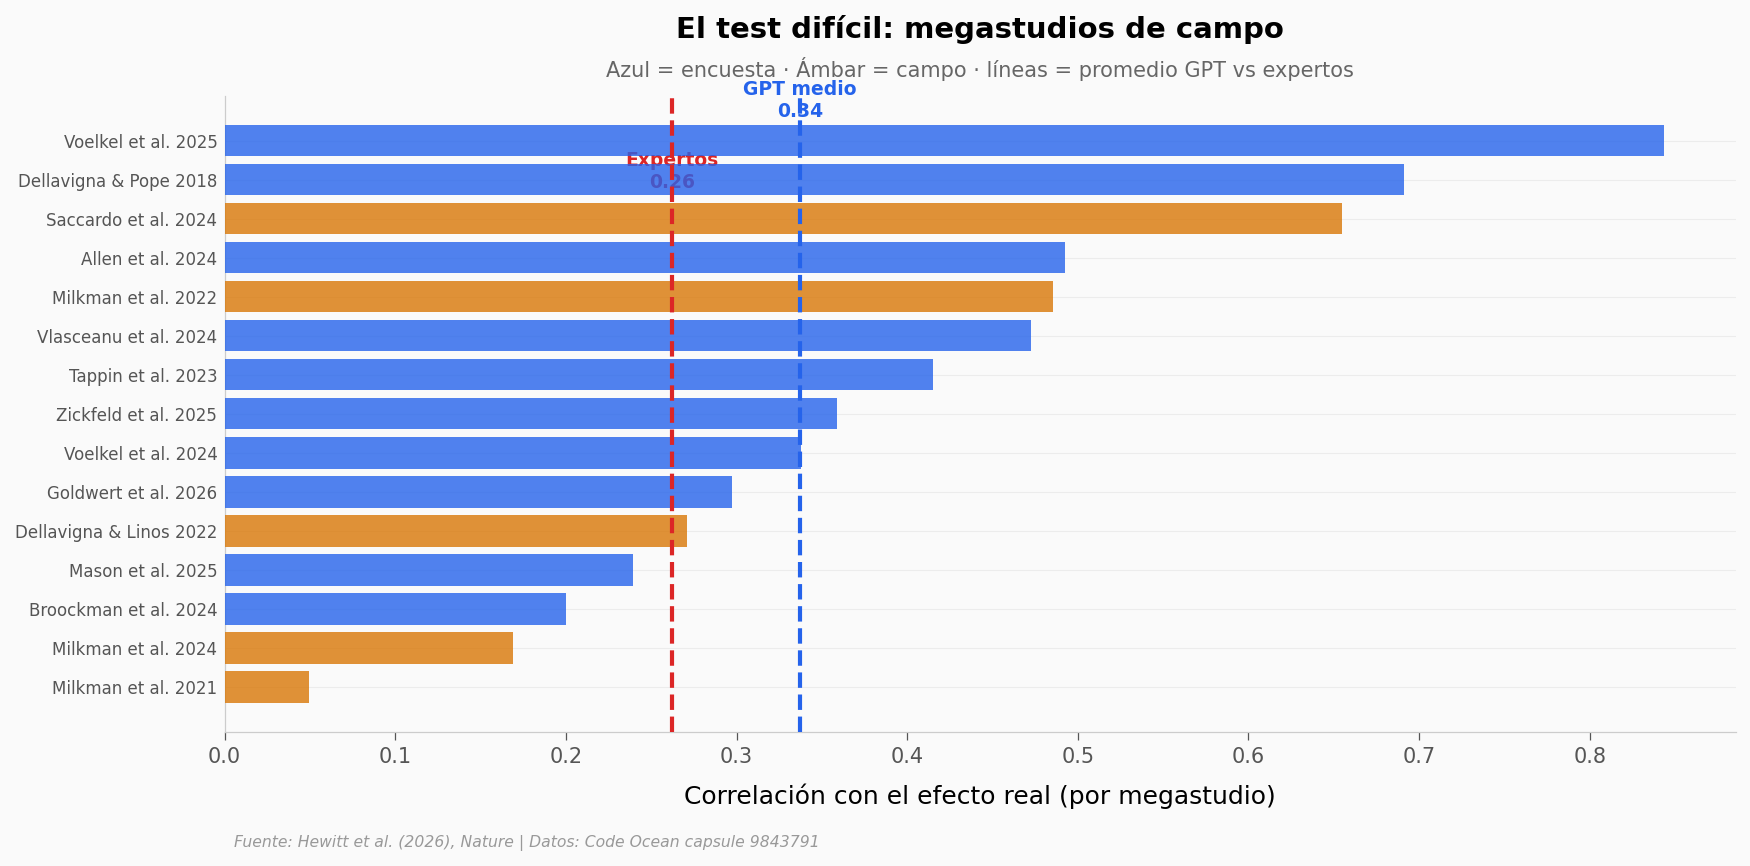

Survey experiments: r medio de GPT = 0.435  (n=10)
Field experiments: r medio de GPT = 0.326  (n=5)

GPT global 0.337  vs  expertos 0.262 — parejo, y ambos modestos.


In [5]:
# --- EXPERIMENTA AQUÍ ---
# El test más duro: megastudios de campo. ¿GPT o los expertos humanos?
indiv = mega[mega['study_label'].notna()].copy()   # los 15 megastudios individuales (solo GPT)
prom = mega[mega['study_label'].isna()].copy()      # filas de promedios

r_gpt_global = prom[prom['predictor'] == 'gpt']['r'].iloc[-1]   # promedio global GPT
r_expertos = prom[prom['predictor'] == 'expert']['r'].iloc[0]

orden = indiv.sort_values('r').reset_index(drop=True)
colores = orden['exp_type'].map({'Survey experiments': COLOR_DATOS,
                                 'Field experiments': COLOR_REFERENCIA})

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.barh(np.arange(len(orden)), orden['r'], color=colores, alpha=0.8, zorder=4)
ax.set_yticks(np.arange(len(orden)))
ax.set_yticklabels(orden['study_label'], fontsize=8)

ax.axvline(r_gpt_global, color=COLOR_DATOS, linewidth=2, linestyle='--', zorder=5)
ax.text(r_gpt_global, len(orden) - 0.4, f'GPT medio\n{r_gpt_global:.2f}',
        color=COLOR_DATOS, fontsize=9, fontweight='bold', ha='center')
ax.axvline(r_expertos, color=COLOR_ALERTA, linewidth=2, linestyle='--', zorder=5)
ax.text(r_expertos, len(orden) - 2.2, f'Expertos\n{r_expertos:.2f}',
        color=COLOR_ALERTA, fontsize=9, fontweight='bold', ha='center')

ax.set_xlabel('Correlación con el efecto real (por megastudio)')
ax.set_title('El test difícil: megastudios de campo',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Azul = encuesta · Ámbar = campo · líneas = promedio GPT vs expertos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/megastudios.png', dpi=200, bbox_inches='tight')
plt.show()

for t in ['Survey experiments', 'Field experiments']:
    sub = indiv[indiv['exp_type'] == t]
    print(f'{t}: r medio de GPT = {sub["r"].mean():.3f}  (n={len(sub)})')
print(f'\nGPT global {r_gpt_global:.3f}  vs  expertos {r_expertos:.3f} — parejo, y ambos modestos.')

## Fuentes

**Paper**: [Large language models can predict the results of social science experiments](https://doi.org/10.1038/s41586-026-10742-x)  
*Nature, 2026-07-08*

**Dataset canónico**: [Reproducibility capsule 9843791 — data & code for 'LLMs can predict the results of social science experiments'](https://codeocean.com/capsule/9843791/tree/v1)

*21 afirmaciones del notebook verificadas contra estas fuentes*